In [9]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# ------------------------
# 1️⃣ 데이터 로딩
# ------------------------
df_risk = pd.read_csv("../data/risk_scored_data_v2_improved.csv")
df_ml = pd.read_csv("../data/ml_scored_data.csv")
df_anomaly = pd.read_csv("../data/anomaly_scored.csv")

# ------------------------
# 2️⃣ 행 정렬
# ------------------------
df_risk = df_risk.reset_index(drop=True)
df_ml = df_ml.reset_index(drop=True)
df_anomaly = df_anomaly.reset_index(drop=True)

# ------------------------
# 3️⃣ 합치기 (먼저)
# ------------------------
df = df_risk.copy()
df["ml_score"] = df_ml["ml_score"]
df["anomaly_score"] = df_anomaly["anomaly_score"]

# ------------------------
# 4️⃣ ML 정규화
# ------------------------
scaler = MinMaxScaler()
df["ml_score"] = scaler.fit_transform(
    df[["ml_score"]]
) * 100


# ------------------------
# 5️⃣ anomaly 정규화 (로그 + clip)
# ------------------------
df["anomaly_score"] = np.log1p(df["anomaly_score"])

upper = df["anomaly_score"].quantile(0.99)
df["anomaly_score"] = df["anomaly_score"].clip(upper=upper)

scaler = MinMaxScaler()
df["anomaly_score"] = scaler.fit_transform(
    df[["anomaly_score"]]
) * 100

# ------------------------
# 6️⃣ Final Score (4:4:2)
# ------------------------
df["final_score"] = (
    df["ml_score"] * 0.4
    + df["risk_score"] * 0.4
    + df["anomaly_score"] * 0.2
).clip(0, 100).round(3)

# ------------------------
# 7️⃣ 확인
# ------------------------
print("\n📊 ml_score")
print(df["ml_score"].describe())

print("\n📊 anomaly_score")
print(df["anomaly_score"].describe())

print("\n📊 final_score")
print(df["final_score"].describe())

print("\n📊 분포")
print(pd.cut(
    df["final_score"],
    bins=[0,20,40,60,80,100]
).value_counts().sort_index())

# ------------------------
# 8️⃣ 저장
# ------------------------
df.to_csv("../data/total_scored_data.csv", index=False)
print("✅ 저장 완료")


📊 ml_score
count    1.296675e+06
mean     6.318496e-01
std      7.620040e+00
min      0.000000e+00
25%      8.456301e-05
50%      3.846632e-04
75%      1.880481e-03
max      1.000000e+02
Name: ml_score, dtype: float64

📊 anomaly_score
count    1.296675e+06
mean     3.205332e+01
std      2.088055e+01
min      0.000000e+00
25%      1.527247e+01
50%      2.802397e+01
75%      4.451302e+01
max      1.000000e+02
Name: anomaly_score, dtype: float64

📊 final_score
count    1.296675e+06
mean     1.786585e+01
std      8.898859e+00
min      5.900000e-02
25%      1.346700e+01
50%      1.771700e+01
75%      2.172400e+01
max      1.000000e+02
Name: final_score, dtype: float64

📊 분포
final_score
(0, 20]      852234
(20, 40]     422407
(40, 60]      13800
(60, 80]       4828
(80, 100]      3406
Name: count, dtype: int64
✅ 저장 완료


In [2]:
# 상위 1% 기준
threshold = 58

top_df = df[df["final_score"] >= threshold]

precision = top_df["is_fraud"].mean()
recall = top_df["is_fraud"].sum() / df["is_fraud"].sum()

print("Precision@Top1%:", precision)
print("Recall@Top1%:", recall)

Precision@Top1%: 0.7343897575821178
Recall@Top1%: 0.9323208100186517


In [3]:
# ------------------------
# 1️⃣ 비율 설정
# ------------------------
top_ratio = 0.006  # 0.6%

# ------------------------
# 2️⃣ threshold 계산
# ------------------------
threshold = df["final_score"].quantile(1 - top_ratio)

# ------------------------
# 3️⃣ 상위 구간 추출
# ------------------------
top_df = df[df["final_score"] >= threshold]

# ------------------------
# 4️⃣ Precision / Recall 계산
# ------------------------
precision = top_df["is_fraud"].mean()

recall = (
    top_df["is_fraud"].sum() /
    df["is_fraud"].sum()
)

print("📌 Threshold:", threshold)
print("📌 Top 건수:", len(top_df))
print("📌 Precision@Top0.6%:", round(precision, 4))
print("📌 Recall@Top0.6%:", round(recall, 4))

📌 Threshold: 60.013
📌 Top 건수: 7795
📌 Precision@Top0.6%: 0.8471
📌 Recall@Top0.6%: 0.8797


In [4]:
print(top_df["is_fraud"].value_counts(normalize=True))

is_fraud
1    0.847081
0    0.152919
Name: proportion, dtype: float64


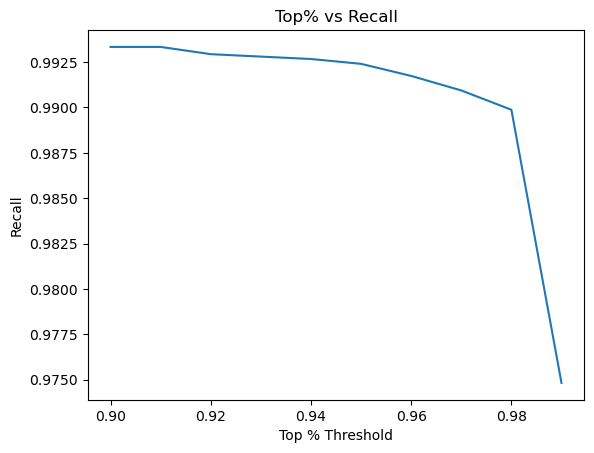

In [3]:
import numpy as np

percentiles = np.arange(0.90, 1.00, 0.01)
recalls = []

for p in percentiles:
    th = df["final_score"].quantile(p)
    tmp = df[df["final_score"] >= th]

    recall = tmp["is_fraud"].sum() / df["is_fraud"].sum()
    recalls.append(recall)

import matplotlib.pyplot as plt
plt.plot(percentiles, recalls)
plt.xlabel("Top % Threshold")
plt.ylabel("Recall")
plt.title("Top% vs Recall")
plt.show()

In [10]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

df_f = pd.read_csv("../data/total_scored_data.csv")
df_f.columns


Index(['merchant', 'category', 'amt', 'gender', 'state', 'zip', 'lat', 'long',
       'city_pop', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud',
       'trans_hour', 'trans_dayofweek', 'trans_month', 'trans_day', 'age',
       'distance_km', 'amt_zscore', 'hour_dev', 'high_amt_far', 'is_night',
       'amt_score', 'time_score', 'high_amt_flag', 'high_amt_score',
       'interaction_score', 'risk_score', 'ml_score', 'anomaly_score',
       'final_score'],
      dtype='str')

C:\Users\young\AppData\Local\Temp\ipykernel_14088\458684405.py:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


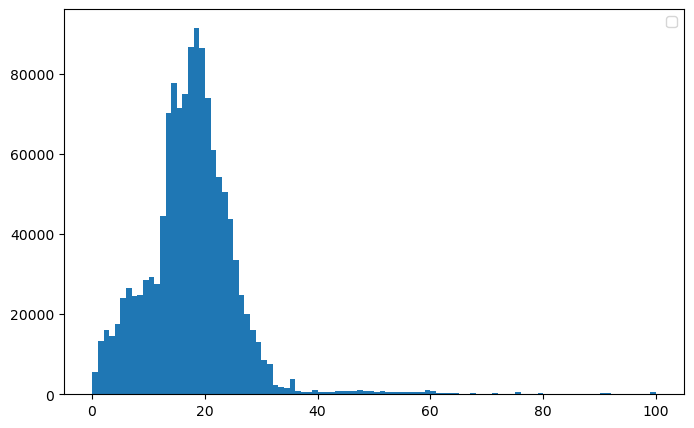

In [11]:

plt.figure(figsize=(8,5))
plt.hist(df_f['final_score'], bins=100)
plt.legend()
plt.show()

In [12]:
df_raw = pd.read_csv("../data/cc_fraud_train.csv")
df_raw.shape
df_raw.columns

Index(['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud'],
      dtype='str')

In [13]:
df_f[['cc_num', 'trans_num', 'first', 'last']] = df_raw[['cc_num', 'trans_num', 'first', 'last']].values
df_f[['cc_num', 'trans_num', 'first', 'last']].head()
df_f.columns
df_f.to_csv("../data/total_scored_data.csv", index=False)
print("✅ 저장 완료")

✅ 저장 완료
